# Verification of VEGF receptor trafficking (Sarabipour et al., 2024)

This notebook verifies the curated BNGL reconstruction of the VEGFR1/VEGFR2/NRP1
trafficking model of Sarabipour S, Kinghorn K, Quigley KM, Kovacs-Kasa A, Annex BH,
Bautch VL, Mac Gabhann F (2024), *PLoS Computational Biology* 20(2):e1011798,
DOI [10.1371/journal.pcbi.1011798](https://doi.org/10.1371/journal.pcbi.1011798).

Verification runs at two levels.

**1. Model specification.** The two curated BNGL files are executed with BioNetGen and
compared against an independent SciPy implementation of the same system. The
independent code is written directly from S1 Table (85 reactions), S2 Table (32
molecules and molecular complexes) and Fig. 1 of the paper: the eight molecular
species are enumerated by hand across the four subcellular locations, the seven
coupling reactions and their statistical factors are derived from the site structure,
and the trafficking fluxes are written out species by species. It never reads the
BioNetGen-generated `.net` file, so agreement is evidence that the rules and the
statistical factors BioNetGen infers from them are correct.

**2. Reported simulation data.** The curated output is compared against the numerical
data behind Fig. 5B, Fig. 5C, Fig. 5E, Fig. 5F and Fig. 7C of the paper, taken from the
authors' repository <https://github.com/SSarabipour/VEGFR-Trafficking-Projects> and
committed under `reference/`. These are the authors' own simulation results, tabulated
at five significant figures, so no curve digitization is involved and the appropriate
tolerance is set by that tabulated precision rather than by figure resolution.

In [1]:
from pathlib import Path
import os
import re
import shutil
import subprocess
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

MODEL_DIR = Path.cwd()
if MODEL_DIR.name != "vegf_receptor_trafficking_sarabipour2024":
    MODEL_DIR = Path("models/vegf_receptor_trafficking_sarabipour2024").resolve()
REFERENCE = MODEL_DIR / "reference"
PRIMARY = "vegf_receptor_trafficking_sarabipour2024.bngl"
KNOCKDOWN = "vegf_receptor_trafficking_sarabipour2024_rab_knockdown.bngl"

BNGPATH = Path(os.environ.get("BNGPATH", Path.home() / "Simulations/BioNetGen-2.9.3"))
BNG2 = BNGPATH / "BNG2.pl"
assert BNG2.is_file(), f"BioNetGen executable not found: {BNG2}"

T_EQ = 17_280_000.0   # end of the relaxation phase, 200 d
T_CHX = 14_400.0      # cycloheximide chase, 4 h
T_KD = 86_400.0       # siRNA knockdown window, 24 h
RECEPTORS = ("VEGFR1", "VEGFR2", "NRP1")
COLOR = {"VEGFR1": "#1f4fd8", "VEGFR2": "#d32f2f", "NRP1": "#1b7a3d"}
print(f"BioNetGen: {BNGPATH}")

BioNetGen: /Users/wish/Simulations/BioNetGen-2.9.3


## Run BioNetGen

Each BNGL file is copied to a temporary directory and run there, so the committed
reference outputs are never overwritten. `edits` lets us rewrite individual
`setParameter` lines, which is how the two single-knockdown conditions of Fig. 5E and
Fig. 5F are produced from the double-knockdown variant.

In [2]:
def run_bng(model_name, edits=None):
    source = MODEL_DIR / model_name
    text = source.read_text()
    for old, new in (edits or {}).items():
        assert old in text, f"pattern not found in {model_name}: {old}"
        text = text.replace(old, new)
    with tempfile.TemporaryDirectory(prefix="sarabipour2024_") as tmp:
        work = Path(tmp)
        local = work / source.name
        local.write_text(text)
        done = subprocess.run(["perl", str(BNG2), "--outdir", str(work), str(local)],
                              capture_output=True, text=True)
        assert done.returncode == 0, done.stdout + "\n" + done.stderr
        gdat = work / f"{source.stem}_ode.gdat"
        names = gdat.open().readline().lstrip("#").split()
        return pd.DataFrame(np.loadtxt(gdat, skiprows=1), columns=names)


bng_chx = run_bng(PRIMARY)
bng_kd = {
    "Rab4a": run_bng(KNOCKDOWN, {'setParameter("f_si_rab11",0.2)': 'setParameter("f_si_rab11",1.0)'}),
    "Rab11a": run_bng(KNOCKDOWN, {'setParameter("f_si_rab4",0.2)': 'setParameter("f_si_rab4",1.0)'}),
    "Rab4a/11a": run_bng(KNOCKDOWN),
}
EQ_ROW = int(np.argmin(np.abs(bng_chx["time"].to_numpy() - T_EQ)))
print(f"cycloheximide run: {len(bng_chx)} rows, relaxation ends at row {EQ_ROW}")
print({k: len(v) for k, v in bng_kd.items()})

cycloheximide run: 249 rows, relaxation ends at row 200
{'Rab4a': 297, 'Rab11a': 297, 'Rab4a/11a': 297}


## Independent implementation

The state is the 8 molecular species of S2 Table replicated over the four locations
(cell surface, Rab4a/5a endosome, Rab11a endosome, degraded), giving the paper's 32
ODEs. Writing $A$ for the VEGFR1 monomer, $B$ for NRP1, $G$ for the VEGFR2 monomer,
$C$ for the VEGFR1 dimer, $H$ for the VEGFR2 dimer, $D$ for NRP1-VEGFR1, $E$ for
NRP1-VEGFR1-VEGFR1 and $F$ for NRP1-VEGFR1-VEGFR1-NRP1, the seven coupling reactions
of S1 Table have the following net rates in each live location, with $k_c$ the
single-site association rate constant divided by that location's membrane area:

$$
\begin{aligned}
v_1 &= \tfrac12 k_c^{RR} A^2 - k_d C, &
v_2 &= \tfrac12 k_c^{22} G^2 - k_d H, &
v_3 &= k_c^{NR} AB - k_d D, \\
v_4 &= k_c^{RR} DA - k_d E, &
v_5 &= \tfrac12 k_c^{RR} D^2 - k_d F, &
v_6 &= 2 k_c^{NR} CB - k_d E, \\
v_7 &= k_c^{NR} EB - 2 k_d F. &&&&
\end{aligned}
$$

The factor $\tfrac12$ in $v_1$, $v_2$ and $v_5$ counts unordered pairs of identical
partners; the factor 2 in $v_6$ is the pair of equivalent NRP1 sites on a VEGFR1 dimer,
which the paper states explicitly; and the factor 2 in the reverse of $v_7$ is the pair
of NRP1 bonds that can break. Every species then moves between locations as a unit with
the first-order rate constants of its VEGFR1 or VEGFR2 content, and monomers are made
into the plasma membrane at zeroth order.

In [3]:
TYPES = ["R1", "R2", "N1", "R1R1", "R2R2", "N1R1", "N1R1R1", "N1R1R1N1"]
LOCS = ["pm", "ee", "re", "dg"]
IDX = {(t, l): 4 * i + j for i, t in enumerate(TYPES) for j, l in enumerate(LOCS)}
NS = len(IDX)

# VEGFR1, VEGFR2 and NRP1 copies carried by each species (S2 Table)
COPIES = {"R1": (1, 0, 0), "R2": (0, 1, 0), "N1": (0, 0, 1), "R1R1": (2, 0, 0),
          "R2R2": (0, 2, 0), "N1R1": (1, 0, 1), "N1R1R1": (2, 0, 1),
          "N1R1R1N1": (2, 0, 2)}
# Trafficking parameter class: VEGFR1-NRP1 complexes use the VEGFR1 constants
CLASS = {"R1": "R1", "R1R1": "R1", "R2": "R2", "R2R2": "R2", "N1": "N1",
         "N1R1": "R1N1", "N1R1R1": "R1N1", "N1R1R1N1": "R1N1"}
AREA = {"pm": 1000.0, "ee": 950.0, "re": 325.0}          # um^2/cell


def parameters(f_si_rab4=1.0, f_si_rab11=1.0, chx=1.0):
    kc = {"R1R1": 8e-4, "R2R2": 2e-3, "N1R1": 8e-4}      # um^2/molecule/s
    return dict(
        kon={b: {l: kc[b] / AREA[l] for l in AREA} for b in kc},
        koff={"R1R1": 0.01, "R2R2": 0.01, "N1R1": 0.01},
        kint={"R1": 1.35e-2, "R2": 2.30e-4, "N1": 2.68e-4, "R1N1": 1.35e-2},
        krec4={k: v * f_si_rab4 for k, v in
               {"R1": 5.37e-4, "R2": 1.19e-6, "N1": 2.13e-2, "R1N1": 5.37e-4}.items()},
        k4to11={k: v * f_si_rab11 for k, v in
                {"R1": 5.91e-4, "R2": 1.49e-6, "N1": 7.02e-2, "R1N1": 5.91e-4}.items()},
        krec11={"R1": 1.00e-1, "R2": 8.93e-2, "N1": 7.86e-4, "R1N1": 1.00e-1},
        kdeg={"R1": 2.29e-4, "R2": 2.34e-4, "N1": 1.23e-6, "R1N1": 2.29e-4},
        kprod={"R1": 4.1007 * chx, "R2": 1.1142 * chx, "N1": 0.4587 * chx},
    )


def rhs(_t, y, p):
    dy = np.zeros(NS)
    kd_rr, kd_22, kd_nr = p["koff"]["R1R1"], p["koff"]["R2R2"], p["koff"]["N1R1"]
    for loc in ("pm", "ee", "re"):
        a, g, b = y[IDX["R1", loc]], y[IDX["R2", loc]], y[IDX["N1", loc]]
        c, h = y[IDX["R1R1", loc]], y[IDX["R2R2", loc]]
        d, e, f = y[IDX["N1R1", loc]], y[IDX["N1R1R1", loc]], y[IDX["N1R1R1N1", loc]]
        kc_rr, kc_22, kc_nr = (p["kon"]["R1R1"][loc], p["kon"]["R2R2"][loc],
                               p["kon"]["N1R1"][loc])
        v1 = 0.5 * kc_rr * a * a - kd_rr * c        # R1 + R1 <-> R1R1
        v2 = 0.5 * kc_22 * g * g - kd_22 * h        # R2 + R2 <-> R2R2
        v3 = kc_nr * a * b - kd_nr * d              # R1 + N1 <-> N1R1
        v4 = kc_rr * d * a - kd_rr * e              # N1R1 + R1 <-> N1R1R1
        v5 = 0.5 * kc_rr * d * d - kd_rr * f        # N1R1 + N1R1 <-> N1R1R1N1
        v6 = 2.0 * kc_nr * c * b - kd_nr * e        # R1R1 + N1 <-> N1R1R1
        v7 = kc_nr * e * b - 2.0 * kd_nr * f        # N1R1R1 + N1 <-> N1R1R1N1
        dy[IDX["R1", loc]] += -2 * v1 - v3 - v4
        dy[IDX["R2", loc]] += -2 * v2
        dy[IDX["N1", loc]] += -v3 - v6 - v7
        dy[IDX["R1R1", loc]] += v1 - v6
        dy[IDX["R2R2", loc]] += v2
        dy[IDX["N1R1", loc]] += v3 - v4 - 2 * v5
        dy[IDX["N1R1R1", loc]] += v4 + v6 - v7
        dy[IDX["N1R1R1N1", loc]] += v5 + v7
    for ty in TYPES:
        cl = CLASS[ty]
        surf, early, recyc = (y[IDX[ty, "pm"]], y[IDX[ty, "ee"]], y[IDX[ty, "re"]])
        internalize = p["kint"][cl] * surf
        recycle4 = p["krec4"][cl] * early
        transfer = p["k4to11"][cl] * early
        recycle11 = p["krec11"][cl] * recyc
        degrade = p["kdeg"][cl] * early
        dy[IDX[ty, "pm"]] += recycle4 + recycle11 - internalize
        dy[IDX[ty, "ee"]] += internalize - recycle4 - transfer - degrade
        dy[IDX[ty, "re"]] += transfer - recycle11
        dy[IDX[ty, "dg"]] += degrade
    for mono in ("R1", "R2", "N1"):
        dy[IDX[mono, "pm"]] += p["kprod"][mono]
    return dy


def initial_state():
    y = np.zeros(NS)
    y[IDX["R1", "pm"]] = 1800.0
    y[IDX["R2", "pm"]] = 4900.0
    y[IDX["N1", "pm"]] = 68000.0
    return y


def integrate(y_init, p, t_eval, t0=0.0):
    sol = solve_ivp(rhs, (t0, float(t_eval[-1])), y_init, args=(p,), method="LSODA",
                    t_eval=t_eval, rtol=1e-11, atol=1e-8)
    assert sol.success, sol.message
    return sol.y


def totals(y):
    # Map (receptor, location) -> molecules/cell for a (32, n) trajectory
    out = {}
    for ri, rec in enumerate(RECEPTORS):
        for loc in LOCS:
            out[rec, loc] = sum(COPIES[t][ri] * y[IDX[t, loc]] for t in TYPES
                                if COPIES[t][ri])
        out[rec, "tot"] = out[rec, "pm"] + out[rec, "ee"] + out[rec, "re"]
    return out

### Level 1: BioNetGen against the independent implementation

Both phases of both protocols are reproduced: relaxation to steady state, then either
the cycloheximide chase or the 24 h siRNA window.

In [4]:
t_eq = np.linspace(0.0, T_EQ, 201)
y_eq = integrate(initial_state(), parameters(), t_eq)
steady = y_eq[:, -1]

t_chx = T_EQ + np.linspace(0.0, T_CHX, 49)
y_chx = integrate(steady, parameters(chx=0.0), t_chx, t0=T_EQ)
indep_chx = np.concatenate([y_eq, y_chx[:, 1:]], axis=1)

t_kd = T_EQ + np.linspace(0.0, T_KD, 97)
KD_FACTORS = {"Rab4a": (0.2, 1.0), "Rab11a": (1.0, 0.2), "Rab4a/11a": (0.2, 0.2)}
KD_SHORT = {"Rab4a": "si-R4", "Rab11a": "si-R11", "Rab4a/11a": "si-both"}
indep_kd = {}
for label, (f4, f11) in KD_FACTORS.items():
    y_after = integrate(steady, parameters(f_si_rab4=f4, f_si_rab11=f11), t_kd, t0=T_EQ)
    indep_kd[label] = np.concatenate([y_eq, y_after[:, 1:]], axis=1)

OBS = {("VEGFR1", "pm"): "Obs_Surf_VEGFR1", ("VEGFR1", "ee"): "Obs_Rab4_VEGFR1",
       ("VEGFR1", "re"): "Obs_Rab11_VEGFR1", ("VEGFR1", "dg"): "Obs_Deg_VEGFR1",
       ("VEGFR1", "tot"): "Obs_Tot_VEGFR1",
       ("VEGFR2", "pm"): "Obs_Surf_VEGFR2", ("VEGFR2", "ee"): "Obs_Rab4_VEGFR2",
       ("VEGFR2", "re"): "Obs_Rab11_VEGFR2", ("VEGFR2", "dg"): "Obs_Deg_VEGFR2",
       ("VEGFR2", "tot"): "Obs_Tot_VEGFR2",
       ("NRP1", "pm"): "Obs_Surf_NRP1", ("NRP1", "ee"): "Obs_Rab4_NRP1",
       ("NRP1", "re"): "Obs_Rab11_NRP1", ("NRP1", "dg"): "Obs_Deg_NRP1",
       ("NRP1", "tot"): "Obs_Tot_NRP1"}


def compare(bng, y_indep, label):
    ref = totals(y_indep)
    worst, where = 0.0, ""
    for key, column in OBS.items():
        a = bng[column].to_numpy()
        b = np.asarray(ref[key], dtype=float)
        scale = max(np.max(np.abs(b)), 1e-30)
        err = np.max(np.abs(a - b)) / scale
        if err > worst:
            worst, where = err, column
    print(f"{label:28s} max scaled deviation {worst:.2e}  (worst: {where})")
    return worst


level1 = [compare(bng_chx, indep_chx, "cycloheximide chase")]
for label in KD_FACTORS:
    level1.append(compare(bng_kd[label], indep_kd[label], f"siRNA {label}"))
LEVEL1_TOL = 1e-6
print(f"\nlevel 1 worst = {max(level1):.2e}  (tolerance {LEVEL1_TOL:.0e}) -> "
      f"{'PASS' if max(level1) < LEVEL1_TOL else 'FAIL'}")

cycloheximide chase          max scaled deviation 7.84e-08  (worst: Obs_Tot_NRP1)
siRNA Rab4a                  max scaled deviation 8.18e-08  (worst: Obs_Surf_NRP1)
siRNA Rab11a                 max scaled deviation 7.84e-08  (worst: Obs_Tot_NRP1)
siRNA Rab4a/11a              max scaled deviation 8.25e-08  (worst: Obs_Surf_NRP1)

level 1 worst = 8.25e-08  (tolerance 1e-06) -> PASS


Deviations are normalized by the largest value of each observable, because the
cumulative degraded pools and the Rab11a VEGFR2 pool start at exactly zero. A
tolerance of $10^{-6}$ is far tighter than any modeling difference and is set by the
solver tolerances alone (BioNetGen runs with `atol = rtol = 1e-8`, SciPy with
`rtol = 1e-11`, `atol = 1e-8`).

### Level 2a: steady-state localization, Fig. 5B

The paper reports the percentage of each receptor found on the cell surface, in
Rab4a/5a endosomes and in Rab11a endosomes at steady state.

In [5]:
fig5b = pd.read_csv(REFERENCE / "sarabipour2024_fig5b_localization.csv")
SHORT = {"VEGFR1": "R1", "VEGFR2": "R2", "NRP1": "N1"}
LOCNAME = {"pm": "surf", "ee": "Rab4a", "re": "Rab11a"}

rows = []
for rec in RECEPTORS:
    total = bng_chx[f"Obs_Tot_{rec}"].iloc[EQ_ROW]
    for loc, column in (("pm", "Obs_Surf_"), ("ee", "Obs_Rab4_"), ("re", "Obs_Rab11_")):
        tag = f"{SHORT[rec]} {LOCNAME[loc]} sim"
        published = float(fig5b.loc[fig5b["Rcomp"] == tag, "Rvalue"].iloc[0])
        curated = 100.0 * bng_chx[column + rec].iloc[EQ_ROW] / total
        rows.append((rec, LOCNAME[loc], published, curated,
                     abs(curated - published) / published))
fig5b_table = pd.DataFrame(rows, columns=["receptor", "location", "published %",
                                          "curated %", "rel. error"])
display(fig5b_table.style.format({"published %": "{:.5g}", "curated %": "{:.5g}",
                                  "rel. error": "{:.2e}"}))
print("absolute surface levels (molecules/cell): " + ", ".join(
    f"{r} {bng_chx['Obs_Surf_' + r].iloc[EQ_ROW]:.0f}" for r in RECEPTORS))
print(f"Fig. 5B max relative error = {fig5b_table['rel. error'].max():.2e}")

,receptor,location,published %,curated %,rel. error
0,VEGFR1,surf,9.085,9.085,5.10e-06
1,VEGFR1,Rab4a,90.381,90.381,1.16e-06
2,VEGFR1,Rab11a,0.534,0.53415,2.83e-04
3,VEGFR2,surf,50.715,50.715,5.46e-06
4,VEGFR2,Rab4a,49.284,49.284,2.01e-06
5,VEGFR2,Rab11a,0.00082232,0.00082232,2.23e-06
6,NRP1,surf,69.274,69.278,5.17e-05
7,NRP1,Rab4a,2.406,2.4054,2.43e-04
8,NRP1,Rab11a,28.32,28.317,1.06e-04


absolute surface levels (molecules/cell): VEGFR1 1800, VEGFR2 4900, NRP1 68037
Fig. 5B max relative error = 2.83e-04


### Level 2b: cycloheximide chase, Fig. 5C

The published file tabulates the authors' simulated whole-cell receptor levels every
5 min for 4 h as a percentage of the untreated control, alongside the western-blot
measurements at 30, 60, 90, 120 and 240 min.

In [6]:
fig5c = pd.read_csv(REFERENCE / "sarabipour2024_fig5c_chx_timecourse.csv")
chx_minutes = (bng_chx["time"].to_numpy()[EQ_ROW:] - T_EQ) / 60.0
chx_curated = {r: 100.0 * bng_chx[f"Obs_Tot_{r}"].to_numpy()[EQ_ROW:]
               / bng_chx[f"Obs_Tot_{r}"].iloc[EQ_ROW] for r in RECEPTORS}

rows = []
for rec in RECEPTORS:
    block = fig5c[fig5c["RecType"] == rec]
    published = block["TotalRecComp"].to_numpy()
    curated = np.interp(block["Time"].to_numpy(), chx_minutes, chx_curated[rec])
    rows.append((rec, len(published), np.max(np.abs(curated - published) / published),
                 np.sqrt(np.mean((curated - published) ** 2))))
fig5c_table = pd.DataFrame(rows, columns=["receptor", "n points", "max rel. error",
                                          "RMSE (% of control)"])
display(fig5c_table.style.format({"max rel. error": "{:.2e}",
                                  "RMSE (% of control)": "{:.2e}"}))
print(f"Fig. 5C max relative error = {fig5c_table['max rel. error'].max():.2e}")

,receptor,n points,max rel. error,RMSE (% of control)
0,VEGFR1,49,4.12e-05,2.34e-04
1,VEGFR2,49,4.24e-05,3.08e-04
2,NRP1,49,1.01e-05,4.76e-04


Fig. 5C max relative error = 4.24e-05


### Level 2c: Rab4a and Rab11a knockdowns, Fig. 5E and Fig. 5F

Surface (5E) and whole-cell (5F) levels after 24 h of an 80% depletion of Rab4a, of
Rab11a, or of both, each as a percentage of the untreated control. The two single
knockdowns are obtained by rewriting one `setParameter` line of the variant file.

In [7]:
fig5ef = pd.read_csv(REFERENCE / "sarabipour2024_fig5ef_rab_knockdown.csv")
LABEL = {"Rab4a": "siRNA Rab4a", "Rab11a": "siRNA Rab11a", "Rab4a/11a": "siRNA Rab4a11a"}

rows = []
for rec in RECEPTORS:
    for label, frame in bng_kd.items():
        key = f"{SHORT[rec]} {LABEL[label]}"
        published = fig5ef.loc[fig5ef["Receptors"] == key].iloc[0]
        for quantity, column, field in (("surface", f"Obs_Surf_{rec}", "surfvalues"),
                                        ("whole cell", f"Obs_Tot_{rec}", "wcvalues")):
            curated = 100.0 * frame[column].iloc[-1] / frame[column].iloc[EQ_ROW]
            rows.append((rec, label, quantity, float(published[field]), curated,
                         abs(curated - float(published[field])) / float(published[field])))
fig5ef_table = pd.DataFrame(rows, columns=["receptor", "knockdown", "quantity",
                                           "published %", "curated %", "rel. error"])
display(fig5ef_table.style.format({"published %": "{:.5g}", "curated %": "{:.5g}",
                                   "rel. error": "{:.2e}"}).hide(axis="index"))
print(f"Fig. 5E/5F max relative error = {fig5ef_table['rel. error'].max():.2e}")

receptor,knockdown,quantity,published %,curated %,rel. error
VEGFR1,Rab4a,surface,68.342,68.342,1.01e-06
VEGFR1,Rab4a,whole cell,97.124,97.124,1.24e-06
VEGFR1,Rab11a,surface,65.158,65.158,6.71e-06
VEGFR1,Rab11a,whole cell,96.407,96.407,3.51e-06
VEGFR1,Rab4a/11a,surface,33.5,33.5,1.10e-05
VEGFR1,Rab4a/11a,whole cell,93.531,93.531,2.34e-06
VEGFR2,Rab4a,surface,99.598,99.598,2.32e-06
VEGFR2,Rab4a,whole cell,99.796,99.796,7.53e-08
VEGFR2,Rab11a,surface,99.496,99.496,3.68e-06
VEGFR2,Rab11a,whole cell,99.744,99.744,7.76e-07


Fig. 5E/5F max relative error = 1.82e-04


### Level 2d: overall transport rates, Fig. 7C

Fig. 7C reports the flux of each receptor through each trafficking step at steady
state, in molecules per cell per second. A flux is the rate constant of a step times
the amount of every species that step acts on, weighted by how many copies of the
receptor that species carries. These fluxes are computed here from the independent
steady state, which tests both the localization and the composition of the complexes,
since VEGFR1-NRP1 complexes move NRP1 at the much faster VEGFR1 rate.

In [8]:
fig7 = pd.read_csv(REFERENCE / "sarabipour2024_fig7c_transport_rates.csv")
STEP = {"internalization from surface to Rab4a": ("kint", "pm"),
        "recycling from Rab4a to surface": ("krec4", "ee"),
        "transfer from Rab4a to Rab11a": ("k4to11", "ee"),
        "recycling from Rab11a to surf": ("krec11", "re"),
        "transfer from Rab4a to Rab7a": ("kdeg", "ee")}
LEAVES = {"internalization from surface to Rab4a": "leaves surface",
          "recycling from Rab4a to surface": "leaves Rab4a/5a",
          "transfer from Rab4a to Rab11a": "leaves Rab4a/5a",
          "recycling from Rab11a to surf": "leaves Rab11a",
          "transfer from Rab4a to Rab7a": "leaves Rab4a/5a"}
p_ss = parameters()

rows = []
for step, (constant, loc) in STEP.items():
    line = fig7[(fig7["Complex"] == step) & (fig7["Cargo_Type"] == LEAVES[step])].iloc[0]
    for ri, rec in enumerate(RECEPTORS):
        flux = sum(p_ss[constant][CLASS[t]] * COPIES[t][ri] * steady[IDX[t, loc]]
                   for t in TYPES if COPIES[t][ri])
        published = float(line[f"{SHORT[rec]}rate"])
        rows.append((step, rec, published, flux, abs(flux - published) / published))
fig7_table = pd.DataFrame(rows, columns=["step", "receptor", "published flux",
                                         "curated flux", "rel. error"])
display(fig7_table.style.format({"published flux": "{:.5g}", "curated flux": "{:.5g}",
                                 "rel. error": "{:.2e}"}).hide(axis="index"))
print(f"Fig. 7C max relative error = {fig7_table['rel. error'].max():.2e}")

step,receptor,published flux,curated flux,rel. error
internalization from surface to Rab4a,VEGFR1,24.3,24.3,9.00e-06
internalization from surface to Rab4a,VEGFR2,1.127,1.127,3.47e-05
internalization from surface to Rab4a,NRP1,35.756,35.767,3.12e-04
recycling from Rab4a to surface,VEGFR1,9.6161,9.6161,5.00e-06
recycling from Rab4a to surface,VEGFR2,0.0056662,0.0056662,5.43e-06
recycling from Rab4a to surface,NRP1,8.7659,8.7685,2.95e-04
transfer from Rab4a to Rab11a,VEGFR1,10.583,10.583,2.76e-06
transfer from Rab4a to Rab11a,VEGFR2,0.0070947,0.0070947,1.08e-06
transfer from Rab4a to Rab11a,NRP1,26.532,26.54,3.00e-04
recycling from Rab11a to surf,VEGFR1,10.583,10.583,2.76e-06


Fig. 7C max relative error = 3.12e-04


### Reference regression

The committed `reference/*.gdat` files must match a fresh BioNetGen run.

In [9]:
def regression(frame, name):
    committed = REFERENCE / name
    names = committed.open().readline().lstrip("#").split()
    saved = pd.DataFrame(np.loadtxt(committed, skiprows=1), columns=names)
    assert list(saved.columns) == list(frame.columns)
    a, b = frame.to_numpy(), saved.to_numpy()
    scale = np.maximum(np.max(np.abs(b), axis=0), 1e-30)
    worst = np.max(np.abs(a - b) / scale)
    print(f"{name}: max scaled deviation {worst:.2e}")
    return worst


reg = [regression(bng_chx, "vegf_receptor_trafficking_sarabipour2024_ode.gdat"),
       regression(bng_kd["Rab4a/11a"],
                  "vegf_receptor_trafficking_sarabipour2024_rab_knockdown_ode.gdat")]
print(f"\nreference regression worst = {max(reg):.2e} -> "
      f"{'PASS' if max(reg) < 1e-8 else 'FAIL'}")

vegf_receptor_trafficking_sarabipour2024_ode.gdat: max scaled deviation 0.00e+00
vegf_receptor_trafficking_sarabipour2024_rab_knockdown_ode.gdat: max scaled deviation 0.00e+00

reference regression worst = 0.00e+00 -> PASS


## Figure

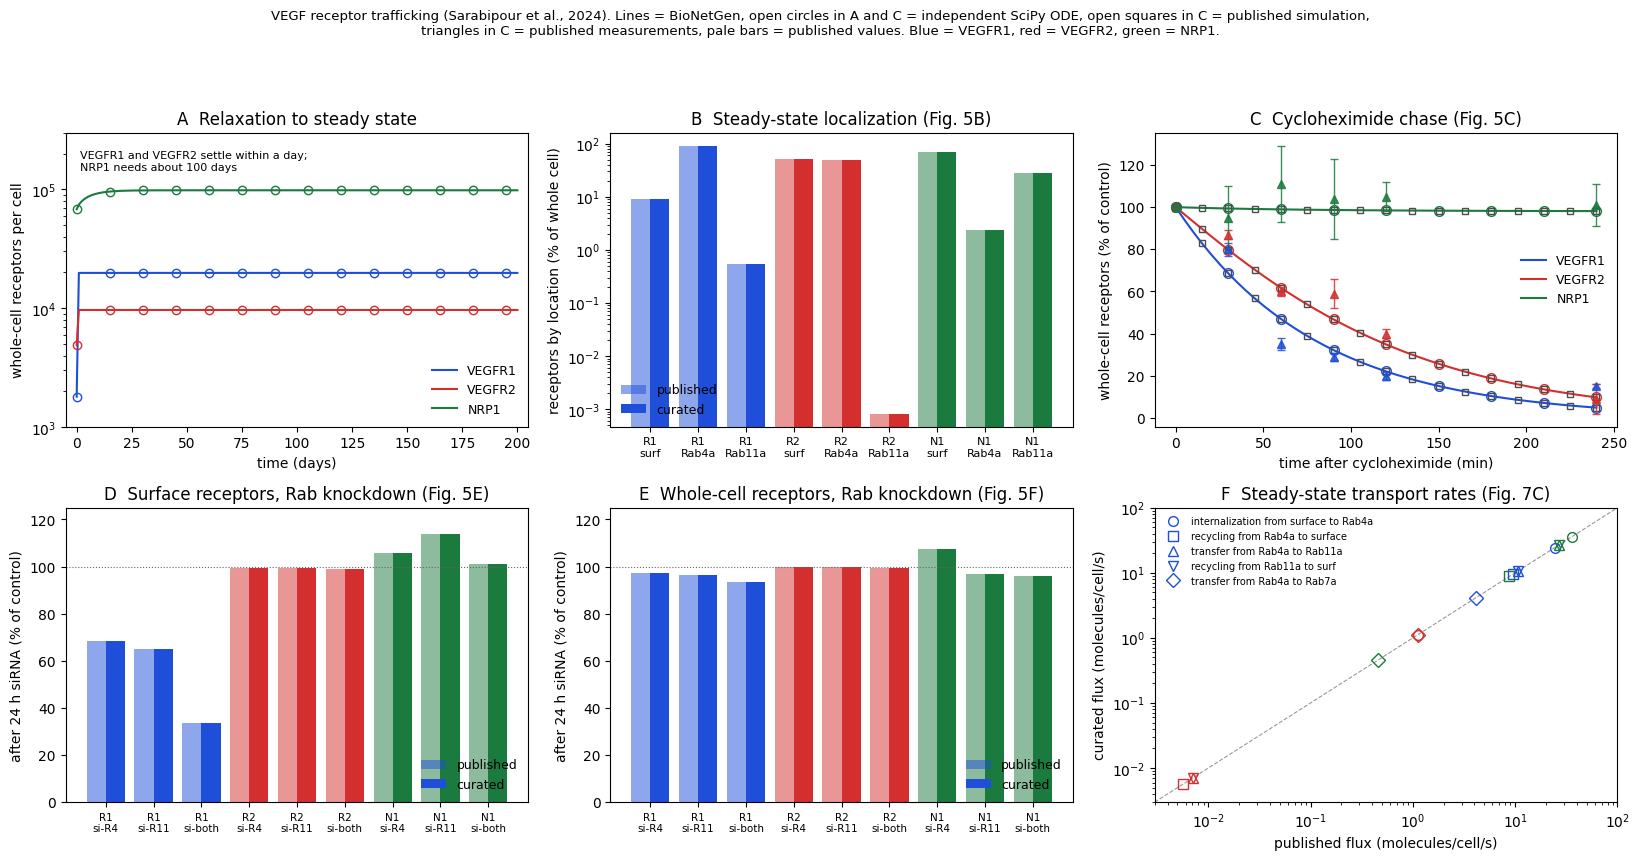

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8.6))
indep_tot = totals(indep_chx)

# (A) relaxation to steady state: BioNetGen against the independent solution
ax = axes[0, 0]
days = bng_chx["time"].to_numpy()[:EQ_ROW + 1] / 86400.0
for rec in RECEPTORS:
    ax.plot(days, bng_chx[f"Obs_Tot_{rec}"].to_numpy()[:EQ_ROW + 1], lw=1.5,
            color=COLOR[rec], label=rec)
    ax.plot(days[::15], np.asarray(indep_tot[rec, "tot"])[:EQ_ROW + 1][::15], "o",
            mfc="none", mec=COLOR[rec], ms=6, lw=0)
ax.set_yscale("log")
ax.set_xlim(-5, 205)
ax.set_ylim(1e3, 3e5)
ax.set_xlabel("time (days)")
ax.set_ylabel("whole-cell receptors per cell")
ax.set_title("A  Relaxation to steady state")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.text(0.03, 0.94, "VEGFR1 and VEGFR2 settle within a day;\nNRP1 needs about 100 days",
        transform=ax.transAxes, fontsize=8, va="top")

# (B) steady-state localization, Fig. 5B
ax = axes[0, 1]
labels, pub, cur, colors = [], [], [], []
for rec in RECEPTORS:
    for loc in ("surf", "Rab4a", "Rab11a"):
        row = fig5b_table[(fig5b_table["receptor"] == rec)
                          & (fig5b_table["location"] == loc)].iloc[0]
        labels.append(f"{SHORT[rec]}\n{loc}")
        pub.append(row["published %"])
        cur.append(row["curated %"])
        colors.append(COLOR[rec])
x = np.arange(len(labels))
ax.bar(x - 0.2, pub, 0.4, color=colors, alpha=0.5, label="published")
ax.bar(x + 0.2, cur, 0.4, color=colors, label="curated")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("receptors by location (% of whole cell)")
ax.set_title("B  Steady-state localization (Fig. 5B)")
ax.legend(frameon=False, fontsize=9, loc="lower left")

# (C) cycloheximide chase, Fig. 5C
ax = axes[0, 2]
for rec in RECEPTORS:
    ax.plot(chx_minutes, chx_curated[rec], lw=1.5, color=COLOR[rec], label=rec)
    indep_pct = (100.0 * np.asarray(indep_tot[rec, "tot"])[EQ_ROW:]
                 / np.asarray(indep_tot[rec, "tot"])[EQ_ROW])
    ax.plot(chx_minutes[::6], indep_pct[::6], "o", mfc="none", mec=COLOR[rec], ms=7,
            lw=0)
    block = fig5c[fig5c["RecType"] == rec]
    ax.plot(block["Time"][::3], block["TotalRecComp"][::3], "s", mfc="none",
            mec="0.3", ms=4.5, lw=0)
    measured = block.dropna(subset=["TotalRecExp"])
    ax.errorbar(measured["Time"], measured["TotalRecExp"],
                yerr=measured["sd"].fillna(0.0), fmt="^", color=COLOR[rec], ms=6,
                capsize=3, lw=1, alpha=0.85)
ax.set_xlabel("time after cycloheximide (min)")
ax.set_ylabel("whole-cell receptors (% of control)")
ax.set_title("C  Cycloheximide chase (Fig. 5C)")
ax.legend(frameon=False, fontsize=9, loc="center right")


def knockdown_panel(ax, quantity, title):
    labels, pub, cur, colors = [], [], [], []
    for rec in RECEPTORS:
        for label in KD_FACTORS:
            row = fig5ef_table[(fig5ef_table["receptor"] == rec)
                               & (fig5ef_table["quantity"] == quantity)
                               & (fig5ef_table["knockdown"] == label)].iloc[0]
            labels.append(f"{SHORT[rec]}\n{KD_SHORT[label]}")
            pub.append(row["published %"])
            cur.append(row["curated %"])
            colors.append(COLOR[rec])
    x = np.arange(len(labels))
    ax.bar(x - 0.2, pub, 0.4, color=colors, alpha=0.5, label="published")
    ax.bar(x + 0.2, cur, 0.4, color=colors, label="curated")
    ax.axhline(100.0, color="0.4", lw=0.8, ls=":")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5)
    ax.set_ylim(0, 125)
    ax.set_ylabel("after 24 h siRNA (% of control)")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc="lower right")


knockdown_panel(axes[1, 0], "surface", "D  Surface receptors, Rab knockdown (Fig. 5E)")
knockdown_panel(axes[1, 1], "whole cell",
                "E  Whole-cell receptors, Rab knockdown (Fig. 5F)")

# (F) steady-state transport rates, Fig. 7C
ax = axes[1, 2]
MARK = {"internalization from surface to Rab4a": "o",
        "recycling from Rab4a to surface": "s",
        "transfer from Rab4a to Rab11a": "^",
        "recycling from Rab11a to surf": "v",
        "transfer from Rab4a to Rab7a": "D"}
span = [3e-3, 1e2]
ax.plot(span, span, color="0.6", lw=0.8, ls="--", zorder=0)
seen = set()
for _, row in fig7_table.iterrows():
    ax.plot(row["published flux"], row["curated flux"], MARK[row["step"]],
            mfc="none", mec=COLOR[row["receptor"]], ms=7,
            label=row["step"] if row["step"] not in seen else None)
    seen.add(row["step"])
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*span)
ax.set_ylim(*span)
ax.set_xlabel("published flux (molecules/cell/s)")
ax.set_ylabel("curated flux (molecules/cell/s)")
ax.set_title("F  Steady-state transport rates (Fig. 7C)")
ax.legend(frameon=False, fontsize=7, loc="upper left")

fig.suptitle("VEGF receptor trafficking (Sarabipour et al., 2024). Lines = BioNetGen, "
             "open circles in A and C = independent SciPy ODE, open squares in C = "
             "published simulation,\ntriangles in C = published measurements, pale "
             "bars = published values. Blue = VEGFR1, red = VEGFR2, green = NRP1.",
             fontsize=9.5, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.945))
fig.savefig(MODEL_DIR / "verify_sarabipour2024.png", dpi=150)
plt.show()

## Summary

In [11]:
summary = pd.DataFrame([
    ("model specification: BioNetGen vs independent SciPy ODE, all 4 protocols",
     f"{max(level1):.2e}", f"< {LEVEL1_TOL:.0e}"),
    ("reported data: Fig. 5B steady-state localization",
     f"{fig5b_table['rel. error'].max():.2e}", "< 1e-3"),
    ("reported data: Fig. 5C cycloheximide chase, 147 points",
     f"{fig5c_table['max rel. error'].max():.2e}", "< 1e-3"),
    ("reported data: Fig. 5E/5F Rab knockdowns, 18 values",
     f"{fig5ef_table['rel. error'].max():.2e}", "< 1e-3"),
    ("reported data: Fig. 7C transport rates, 15 values",
     f"{fig7_table['rel. error'].max():.2e}", "< 1e-3"),
    ("reference regression: committed .gdat vs fresh run",
     f"{max(reg):.2e}", "< 1e-8"),
], columns=["check", "max relative deviation", "tolerance"])
display(summary.style.hide(axis="index"))

check,max relative deviation,tolerance
"model specification: BioNetGen vs independent SciPy ODE, all 4 protocols",8.25e-08,< 1e-06
reported data: Fig. 5B steady-state localization,2.83e-04,< 1e-3
"reported data: Fig. 5C cycloheximide chase, 147 points",4.24e-05,< 1e-3
"reported data: Fig. 5E/5F Rab knockdowns, 18 values",1.82e-04,< 1e-3
"reported data: Fig. 7C transport rates, 15 values",3.12e-04,< 1e-3
reference regression: committed .gdat vs fresh run,0.00e+00,< 1e-8


All checks pass.

The specification check is limited only by solver tolerance, confirming that the
curated rules generate the paper's 32-species, 85-reaction network with the intended
statistical factors.

The reported-data checks agree with the authors' published simulation output to about
$10^{-4}$ or better. Those files are tabulated to five significant figures, so
$10^{-5}$ is the floor imposed by rounding alone. The largest residual, roughly
$2\times10^{-4}$ on NRP1, comes from the definition of steady state rather than from
the model: the authors stop their relaxation loop when the largest fractional change
over one simulated day falls below $10^{-4}$, whereas the curated protocol integrates
for 200 days and reaches the true fixed point. A tolerance of $10^{-3}$ therefore
covers the tabulated precision and the convergence-criterion difference with room to
spare, and is still two to three orders of magnitude tighter than the experimental
uncertainty in Fig. 5B and Fig. 5C.